# Cat Health Agentic RAG with LangChain and LangGraph

In Session 1, retrieval happened before every answer:

```text
question -> retrieve -> generate
```

In this notebook, retrieval becomes a **tool**. The agent can call that tool when it decides the user's question needs cat health guideline context.

That is the core idea of agentic RAG for this session:

```text
question -> agent decides whether to retrieve -> optional retrieval tool call -> answer
```

We will show that loop two ways:

1. **High-level LangChain path**: use `create_agent` with middleware.
2. **Explicit LangGraph path**: build the same loop with `StateGraph`, `ToolNode`, and `tools_condition`.

Both versions use the same retriever tool. The point is to see that agentic RAG is about giving the agent retrieval as an action, not forcing retrieval as a pre-step.

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how agentic RAG differs from a fixed two-step RAG pipeline.
- Build and inspect a retrieval tool over a Qdrant vector store.
- Use LangChain middleware to observe and constrain an agent loop.
- Compare the convenience of `create_agent` with the control of an explicit LangGraph graph.
- Design focused routing and middleware experiments for an agentic RAG system.

## Table of Contents

- **Breakout Room #1: High-Level Agentic RAG with LangChain**
  - Task 1: Environment Setup
  - Task 2: Load and Index the Cat Health Corpus
  - Task 3: Create a Retriever Tool
  - Task 4: Build an Agent with `create_agent` and Middleware
  - Task 5: Visualize and Stream the `create_agent` Agent
  - 🏗️ Activity #1: Add a Retriever Tool-Call Budget
- **Breakout Room #2: Explicit Agent Loop with LangGraph**
  - Task 6: Build the Same Agent Loop with LangGraph
  - 🏗️ Activity #2: Add Deterministic Scope Routing
  - 🚧 Advanced Build: Add Explicit Retrieval extended_routing Control

---
# Breakout Room #1
## High-Level Agentic RAG with LangChain

In this breakout room, you will build the shared retrieval tool, give it to `create_agent`, and use middleware and streaming to inspect and constrain the agent loop.

## Task 1: Environment Setup

From the `02_Agentic_RAG_LangGraph_LangChain` folder, install dependencies with uv:

```bash
uv sync
```

Then open this notebook in Cursor or VS Code and select the Python/Jupyter environment created by uv.

### Imports

LangChain gives us document loading, splitting, embeddings, Qdrant integration, tools, models, and the high-level agent loop.

In [1]:
from pathlib import Path
from getpass import getpass
import os

from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware, ToolCallLimitMiddleware, before_model
from langchain.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_core.messages import SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

/tmp/ipykernel_9374/1608185913.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


### API Keys and Models

The chat model and embedding model both use OpenAI. If `OPENAI_API_KEY` is not already set in your environment, this cell will ask for it securely.

LangSmith tracing is optional. If you set `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY`, LangChain/LangGraph calls will be traced automatically.

In [2]:
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

if not os.environ.get("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass("LangSmith API Key: ")    

os.environ.setdefault("LANGSMITH_TRACING", "true")
os.environ.setdefault("LANGSMITH_PROJECT", "aim-session-3-agentic-rag")

chat_model_name = os.environ.get("AIM_CHAT_MODEL", "gpt-5.4-mini")
embedding_model_name = os.environ.get("AIM_EMBEDDING_MODEL", "text-embedding-3-small")

llm = ChatOpenAI(model=chat_model_name)
embeddings = OpenAIEmbeddings(model=embedding_model_name)

print(f"Chat model: {chat_model_name}")
print(f"Embedding model: {embedding_model_name}")
print(f"LangSmith tracing: {os.environ.get('LANGSMITH_TRACING', 'false')}")

Chat model: gpt-5.4-mini
Embedding model: text-embedding-3-small
LangSmith tracing: true


## Task 2: Load and Index the Cat Health Corpus

We will use a small course-owned Markdown corpus instead of a PDF. This keeps the session focused on the agentic RAG pattern instead of PDF parsing.

**Further Reading:**
- [LangChain Retrieval](https://docs.langchain.com/oss/python/langchain/retrieval)
- [Qdrant LangChain Integration](https://qdrant.tech/documentation/frameworks/langchain/)

In [3]:
corpus_path = Path("data/cat_health_guidelines.md")

if not corpus_path.exists():
    raise FileNotFoundError(
        f"Expected the cat health corpus at: {corpus_path.resolve()}\n"
        "Run this notebook from the 02_Agentic_RAG_LangGraph_LangChain folder."
    )

loader = TextLoader(str(corpus_path), encoding="utf-8")
documents = loader.load()

for document in documents:
    document.metadata["source"] = corpus_path.name
    document.metadata["document_type"] = "cat_health_guidelines"

print(f"Loaded {len(documents)} document(s).")
print(documents[0].page_content[:800])
print("\nMetadata:", documents[0].metadata)

Loaded 1 document(s).
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic disease, and cats taking long-term medication may need more frequent visits. A wellness visit may include a weight check, dental exam, vaccine review, parasite prevention review, and discussion of behavior, appetite, hydration, litter box habits, and activity level.

Preventive care is easier when owners track small changes over time. Useful observations include body weight, appetite, drinking, uri

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines'}


### Split the Corpus

Chunks should be large enough to keep a useful idea together, but small enough that retrieval returns focused context.

In [4]:
chunk_size = 900
chunk_overlap = 120

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    add_start_index=True,
    separators=["\n## ", "\n### ", "\n\n", "\n", ". ", " "],
)

splits = text_splitter.split_documents(documents)

for index, split in enumerate(splits):
    split.metadata["chunk_id"] = index

print(f"Created {len(splits)} chunks.")
print(splits[0].page_content[:800])
print("\nMetadata:", splits[0].metadata)

Created 10 chunks.
# Cat Health Guidelines

This short teaching corpus is for AI Makerspace retrieval exercises. It is not veterinary advice. Students should use it to practice grounding answers in retrieved context and should recommend contacting a veterinarian for medical decisions.

Metadata: {'source': 'cat_health_guidelines.md', 'document_type': 'cat_health_guidelines', 'start_index': 0, 'chunk_id': 0}


### Build the Qdrant Vector Store

For the course notebook, Qdrant runs in memory. There is no Docker service or cloud account required, and the collection disappears when the notebook kernel stops.

In [5]:
collection_name = "cat_health_agentic_rag"

vector_store = QdrantVectorStore.from_documents(
    documents=splits,
    embedding=embeddings,
    location=":memory:",
    collection_name=collection_name,
)

retrieval_k = 4
print(f"Built in-memory Qdrant collection: {collection_name}")

Built in-memory Qdrant collection: cat_health_agentic_rag


## Task 3: Create a Retriever Tool

This is the important shift from Session 1.

The retriever is no longer a required pre-step. It is now a tool the agent can call when it wants context from the cat health guideline corpus.

The tool name, docstring, inputs, and output format form a contract with the model. Clear contracts make good tool-selection and grounded-answer behavior more likely.

**Further Reading:**
- [LangChain Tools](https://docs.langchain.com/oss/python/langchain/tools)
- [ReAct: Synergizing Reasoning and Acting in Language Models](https://arxiv.org/abs/2210.03629)

In [6]:
def _format_retrieved_docs(scored_docs: list[tuple]) -> str:
    formatted_chunks = []
    for index, (doc, score) in enumerate(scored_docs, start=1):
        source = doc.metadata.get("source", "unknown")
        chunk_id = doc.metadata.get("chunk_id", "unknown")
        start_index = doc.metadata.get("start_index", "unknown")
        score_text = f"{score:.3f}" if isinstance(score, (float, int)) else str(score)
        formatted_chunks.append(
            f"[Source {index}: {source}, chunk_id={chunk_id}, start_index={start_index}, score={score_text}]\n"
            f"{doc.page_content.strip()}"
        )
    return "\n\n".join(formatted_chunks)


@tool
def retrieve_cat_health_guidelines(query: str) -> str:
    """Search the cat health guideline corpus for relevant context about cat preventive care, nutrition, hydration, vaccines, parasites, dental health, urinary warning signs, emergencies, senior cats, stress, behavior, and safe home monitoring."""
    results = vector_store.similarity_search_with_score(query, k=retrieval_k)
    if not results:
        return "No relevant cat health guideline context found."
    return _format_retrieved_docs(results)


retriever_tool = retrieve_cat_health_guidelines

Try the tool directly once. This is just to understand what the agent will see when it calls the tool.

In [7]:
print(
    retriever_tool.invoke(
        {"query": "What urinary signs suggest a cat needs urgent veterinary care?"}
    )[:2500]
)

[Source 1: cat_health_guidelines.md, chunk_id=5, start_index=3071, score=0.673]
## Symptoms That Need Veterinary Attention

Veterinary attention is recommended when a cat has trouble breathing, collapse, seizures, severe weakness, suspected poisoning, trauma, uncontrolled bleeding, repeated vomiting, repeated diarrhea, inability to urinate, straining to urinate, pale gums, severe pain, or a swollen painful abdomen.

Non-emergency changes can still matter. Schedule a veterinary visit for persistent appetite changes, weight loss, increased thirst, increased urination, new hiding, aggression, overgrooming, hair loss, bad breath, drooling, limping, coughing, sneezing that does not improve, or behavior that is unusual for the cat.

[Source 2: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.666]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention

In [27]:
print(
    retriever_tool.invoke(
        {"query": "Who won the 2022 FIFA world cup?"}
    )[:2500]
)

[Source 1: cat_health_guidelines.md, chunk_id=2, start_index=997, score=0.026]
## Vaccines And Parasite Prevention

Core vaccines are commonly recommended for cats because they protect against serious contagious diseases. Vaccine schedules depend on age, prior vaccine history, local disease risk, indoor or outdoor lifestyle, and veterinarian guidance. Cats that go outdoors, live with other animals, board, travel, or have unknown exposure risk may need additional protection.

Parasite prevention should be discussed with a veterinarian. Fleas, ticks, ear mites, intestinal worms, and heartworm can affect cats. Indoor cats can still be exposed when parasites enter the home on people, other pets, or objects. Never give a cat a dog parasite medication unless a veterinarian specifically prescribes it for that cat, because some dog products are toxic to cats.

[Source 2: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.001]
## Litter Box And Urinary Warning Signs

Changes in lit

#### ❓ Question #1

What changes when retrieval becomes a tool instead of a mandatory first step?

##### Answer:

When retrieval becomes a tool instad of a mandatory first step, the llm can first refine the original query, and then make a decision to use the tool, if its description (in docstring) fits the query. also, it can loop using the tool before it generates an answer. instead of retrieval being a strate line of query->retrieval->generation, it becomes a state machine with looping and branching. on the downside, the llm can make wrong decisions - Like skipping retrieval when it should have searched, and then hallucinating an ungrounded answer, or looping excessive times with the tool. Which is why its important to limit tool calling to a maximal amount.

## Task 4: Way 1 - Build an Agent with `create_agent` and Middleware

`create_agent` builds the agent loop for us:

1. The model reads the user question and available tools.
2. The model either answers directly or asks to call a tool.
3. If it asks for a tool, LangChain executes the tool.
4. The tool result is added back to the message history.
5. The model continues until it produces a final answer.

This is the fastest way to build agentic RAG: give the agent a retriever tool and let the agent decide when to call it.

Middleware hooks into the loop without requiring us to rebuild the graph. Below, custom `before_model` middleware logs each model step, while built-in middleware limits the number of model calls in one run.

**Further Reading:**
- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)

In [9]:
AGENT_SYSTEM_PROMPT = """You are a cat health guideline assistant in an agentic RAG lesson.

You have one retrieval tool: retrieve_cat_health_guidelines.

Use the retrieval tool when the user asks about cat health, cat symptoms, preventive care, nutrition, vaccines, parasites, dental health, urinary signs, senior cats, stress, behavior, or home monitoring.

When you use retrieved context:
- Answer only from that retrieved context.
- Include a short Sources line using the source labels returned by the tool.
- Remind the user to contact a veterinarian for medical decisions, urgent symptoms, or worsening symptoms.

If the user asks something unrelated to cat health, do not call the tool. Briefly say this notebook is scoped to the cat health guideline corpus.
If the retrieved context does not contain enough information, say you do not have enough information in the cat health guidelines to answer.
"""


@before_model
def log_before_model(state, runtime):
    """Log a compact view of each model step in the agent loop."""
    print(f"[middleware] Calling the model with {len(state['messages'])} message(s).")


agent_middleware = [
    log_before_model,
    ModelCallLimitMiddleware(run_limit=4, exit_behavior="end"),
]


agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware,
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


#### ❓ Question #2

What does middleware let us change or observe without rebuilding the agent loop? Why is a model-call limit useful?

##### Answer:

Middleware wraps around steps in the agent loop, and by observing the state, it can either print out the state for us to to debug unexpected behavior, or limit the number of times the agent loop can retry using a tool (without changing the agent loop), so it won't keep calling tools excessive times, burning cost and increasing latency, and even possiblly not terminating.

## Task 5: Visualize and Stream the `create_agent` Agent

`create_agent` returns a compiled LangGraph graph. We can visualize that graph and stream updates to inspect when the retriever tool was called.

The exact generated graph includes middleware nodes, but its core loop is:

```text
START -> before-model middleware -> model -> after-model middleware -> END
                                                |
                                                | tool call
                                                v
                                              tools
                                                |
                                                +----> loop back to before-model middleware
```

**Further Reading:**
- [LangGraph Streaming](https://docs.langchain.com/oss/python/langgraph/streaming)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Visualize the `create_agent` Graph

Run the next cell to render the exact compiled graph, including middleware nodes. If Mermaid PNG rendering is unavailable in your environment, the fallback prints the Mermaid source.

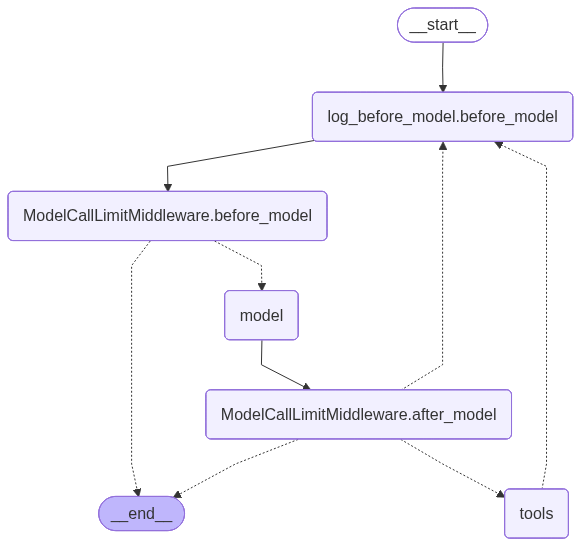

In [25]:
try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream Agent Runs

Streaming updates lets us inspect the path the agent took. Look for tool messages to see when retrieval happened.

In [ ]:
def print_agent_stream(question: str):
    """Run the agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if update is None:
                print("No state update returned.")
                continue

            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Example 1: Cat Health Question

This should call the retrieval tool before answering.

In [11]:
print_agent_stream("What urinary signs suggest my cat needs urgent veterinary care?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_GfKwbRe2Y8nLaKP8N6xHNKe9)
 Call ID: call_GfKwbRe2Y8nLaKP8N6xHNKe9
  Args:
    query: urinary signs urgent veterinary care cat warning signs emergency trouble urinating blood straining no urine

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.696]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners

### Example 2: Another Cat Health Question

This should also retrieve, but with a different search query.

In [12]:
print_agent_stream("What preventive care should an adult cat get each year?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_1QE0Gw5OoY0ak81FzbAhEgsI)
 Call ID: call_1QE0Gw5OoY0ak81FzbAhEgsI
  Args:
    query: preventive care adult cat each year annual preventive care wellness exam vaccines parasite prevention dental care nutrition hydration home monitoring

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=1, start_index=268, score=0.795]
## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats wit

### Example 3: Unrelated Question

This should not call the retrieval tool.

In [13]:
print_agent_stream("Who won the 2022 FIFA World Cup?")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t answer that general knowledge question here.

--- Update from node: ModelCallLimitMiddleware.after_model ---
{'thread_model_call_count': 1, 'run_model_call_count': 1}


#### ❓ Question #3

For each example, did the agent call the retrieval tool? Why or why not?

##### Answer:

Example 1: What urinary signs suggest my cat needs urgent veterinary care?
- The agent called the retrieval tool. The original query was already specific, and after refining it by the llm [urinary signs urgent veterinary care cat warning signs emergency trouble urinating blood straining no urine], it called the tool in that same turn. Then it proceeded to generate an answer based on the retrieved context.
Example 2: What preventive care should an adult cat get each year?
- The agent also called the retrieval tool for the same reasons in Example 1.
Example 3: Who won the 2022 FIFA World Cup?
- The agent decided to skip the tool call. As stated in the system prompt, "If the user asks something unrelated to cat health, do not call the tool. Briefly say this notebook is scoped to the cat health guideline corpus." 
- The agent's response was "This notebook is scoped to the cat health guideline corpus, so I can’t answer that general knowledge question here.", as instructed in the system prompt

## 🏗️ Activity #1: Add a Retriever Tool-Call Budget

Middleware can enforce an operational rule without changing the retriever tool or rebuilding the agent graph. Create a second agent that allows at most **one** call to `retrieve_cat_health_guidelines` per run.

### Requirements

1. Create a `ToolCallLimitMiddleware` instance scoped to `retriever_tool.name` with `run_limit=1` and `exit_behavior="continue"`.
2. Create `budgeted_agent` with the same model, tool, prompt, and existing middleware plus the new retrieval budget.
3. Ask the agent to use separate searches for urinary emergency signs and annual preventive care before summarizing both.
4. Inspect the stream and explain what the middleware allowed or blocked.

**Further Reading:**
- [Built-in Middleware](https://docs.langchain.com/oss/python/langchain/middleware/built-in)

In [10]:
# Activity #1 workspace
# retrieval_budget = ToolCallLimitMiddleware(...)
# budgeted_agent = create_agent(...)

### YOUR CODE HERE


from typing import Any


retrieval_budget = ToolCallLimitMiddleware(tool_name=retriever_tool.name, run_limit=1, exit_behavior="continue")

budgeted_agent = create_agent(
    model=llm,
    tools=[retriever_tool],
    system_prompt=AGENT_SYSTEM_PROMPT,
    middleware=agent_middleware + [retrieval_budget],
)

def print_budgeted_agent_stream(question: str):
    """Run the agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in budgeted_agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            if update is None:
                print("No state update returned.")
                continue

            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

print_budgeted_agent_stream("What urinary signs suggest my cat needs urgent veterinary care? what annual preventive care should an adult cat get? use separate searches for each question and then summarize the results")

[middleware] Calling the model with 1 message(s).

--- Update from node: log_before_model.before_model ---
No state update returned.

--- Update from node: ModelCallLimitMiddleware.before_model ---
No state update returned.

--- Update from node: model ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_bWp2DnZZptZvJHWS45vzrpyG)
 Call ID: call_bWp2DnZZptZvJHWS45vzrpyG
  Args:
    query: urinary signs urgent veterinary care cat emergency warning signs
  retrieve_cat_health_guidelines (call_WPmZG5mRXwCl5piHxAjjw154)
 Call ID: call_WPmZG5mRXwCl5piHxAjjw154
  Args:
    query: annual preventive care for an adult cat vaccines parasite prevention dental exam wellness exam nutrition weight monitoring

--- Update from node: ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model ---
Tool result preview:
Tool call limit exceeded. Do not call 'retrieve_cat_health_guidelines' again.

--- Update from nod

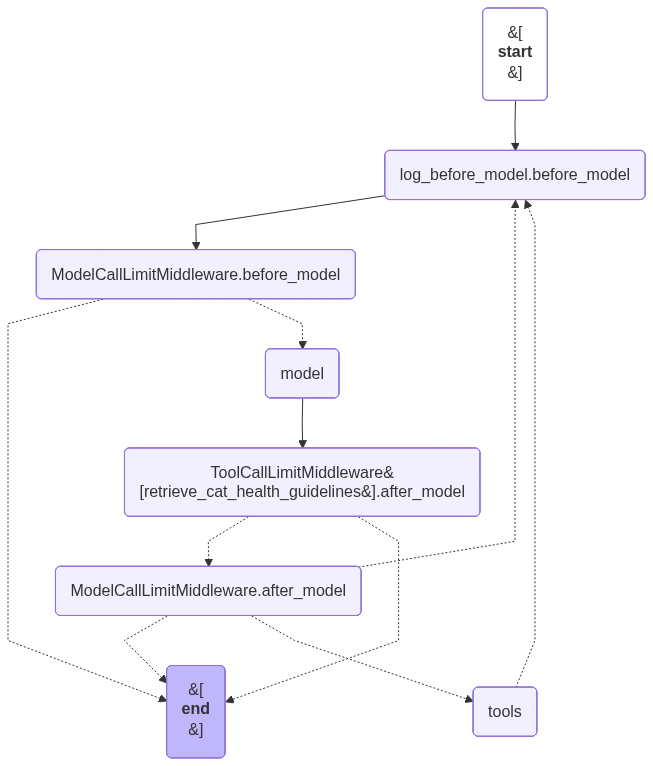

In [26]:
import base64, requests
from IPython.display import Image, display

def render_agent_graph(agent):
    mermaid = agent.get_graph().draw_mermaid()
    # mermaid.ink rejects literal [ ] inside (...) labels; entities render as real brackets
    mermaid = mermaid.replace("[", "&#91;").replace("]", "&#93;")
    enc = base64.b64encode(mermaid.encode("utf8")).decode("ascii")
    url = f"https://mermaid.ink/img/{enc}?type=png&bgColor=!white"
    resp = requests.get(url, timeout=15)
    resp.raise_for_status()
    display(Image(resp.content))

render_agent_graph(budgeted_agent)

In [24]:
try:
    display(Image(budgeted_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(budgeted_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

Could not render Mermaid PNG. Mermaid source follows:

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	tools(tools)
	log_before_model\2ebefore_model(log_before_model.before_model)
	ModelCallLimitMiddleware\2ebefore_model(ModelCallLimitMiddleware.before_model)
	ModelCallLimitMiddleware\2eafter_model(ModelCallLimitMiddleware.after_model)
	ToolCallLimitMiddleware\5bretrieve_cat_health_guidelines\5d\2eafter_model(ToolCallLimitMiddleware[retrieve_cat_health_guidelines].after_model)
	__end__([<p>__end__</p>]):::last
	ModelCallLimitMiddleware\2eafter_model -.-> __end__;
	ModelCallLimitMiddleware\2eafter_model -.-> log_before_model\2ebefore_model;
	ModelCallLimitMiddleware\2eafter_model -.-> tools;
	ModelCallLimitMiddleware\2ebefore_model -.-> __end__;
	ModelCallLimitMiddleware\2ebefore_model -.-> model;
	ToolCallLimitMiddleware\5bretrieve_cat_health_guidelines\5d\2eafter_model -.-> ModelCallLimitMiddleware\2eafter_model;
	ToolCall

### 📝 Activity #1 Notes

- Which retrieval calls did the agent attempt?



- What quality or safety trade-off does this budget introduce?

##### Answer:

  - The agent attempted 2 retrieval calls:
            Tool Calls:
            retrieve_cat_health_guidelines (call_bWp2DnZZptZvJHWS45vzrpyG)
            Call ID: call_bWp2DnZZptZvJHWS45vzrpyG
            Args:
                query: urinary signs urgent veterinary care cat emergency warning signs
            retrieve_cat_health_guidelines (call_WPmZG5mRXwCl5piHxAjjw154)
            Call ID: call_WPmZG5mRXwCl5piHxAjjw154
            Args:
                query: annual preventive care for an adult cat vaccines parasite prevention dental exam wellness exam nutrition weight monitoring

  - The middleware alloweded one of the tool calls and blocked the other. 
  - The current budget increased the safety of the agent by preventing abuse, when a prompt is trying direct it to use multiple tool calls even when its not necessary. On the other hand, limiting the budget too much won't allow the agent to use the necessary tool calls to retrieve all the needed context to fully answer questions. In this example, quality was hit by preventing the agent from fetching the context from the second question in the query, resulting in trying answering the second question with: "The retrieved guidelines did not give a detailed adult-cat annual preventive care schedule but they do support: ..." and trying to leverage the unrelated context retrieved by the first query.

## Breakout Room #1 Summary

In BOR1, you:

- Turned retrieval into a source-labeled tool the model can choose to call.
- Built a high-level agent loop with `create_agent`.
- Used middleware to observe the loop and constrain model or tool calls.
- Used streaming to inspect retrieval decisions instead of judging only the final answer.

---
# Breakout Room #2
## Explicit Agent Loop with LangGraph

In this breakout room, you will rebuild the same model-tools loop explicitly, then add routing behavior that would require graph-level control.

## Task 6: Way 2 - Build the Same Agent Loop with LangGraph

Now we will build the minimal agent loop ourselves.

This is the same idea as `create_agent`, but expressed directly as a graph:

```text
START -> agent model -------------------------------> END
              |
              | tool call
              v
            tools
              |
              +---------------------> agent model
```

There is still no mandatory pre-retrieval step. Retrieval only happens if the model emits a tool call. Unlike middleware, graph nodes and conditional edges let us change the control flow itself.

**Further Reading:**
- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)
- [LangGraph Workflows and Agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)

In [11]:
llm_with_tools = llm.bind_tools([retriever_tool])


def call_model(state: MessagesState):
    """Call the model with tools bound so it can choose whether to retrieve."""
    response = llm_with_tools.invoke(
        [SystemMessage(content=AGENT_SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}


langgraph_builder = StateGraph(MessagesState)
langgraph_builder.add_node("agent", call_model)
langgraph_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))

langgraph_builder.add_edge(START, "agent")
langgraph_builder.add_conditional_edges("agent", tools_condition)
langgraph_builder.add_edge("tools", "agent")

langgraph_agent = langgraph_builder.compile()
print("Compiled the explicit LangGraph agent loop.")

Compiled the explicit LangGraph agent loop.


### Visualize the Explicit LangGraph Agent

This graph should look like the core agent loop: model node, tools node, and a conditional route between them.

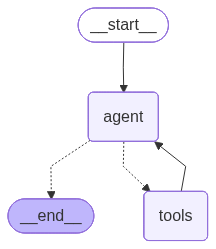

In [12]:
try:
    display(Image(langgraph_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(langgraph_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

### Stream the Explicit LangGraph Agent

This helper is intentionally similar to `print_agent_stream`. The difference is that we are streaming from the graph we built ourselves.

In [13]:
def print_langgraph_stream(question: str):
    """Run the explicit LangGraph agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in langgraph_agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

### Compare the Same Questions

Run the same style of questions through the explicit LangGraph agent. The exact wording may differ, but the retrieval decision should follow the same pattern.

In [16]:
print_langgraph_stream("What urinary signs suggest my cat needs urgent veterinary care?")


--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_b4KwTMYotwfwG4W3CTlRDoAC)
 Call ID: call_b4KwTMYotwfwG4W3CTlRDoAC
  Args:
    query: urinary signs urgent veterinary care in cats blood in urine straining frequent attempts inability to urinate pain vocalizing urinating outside litter box emergency

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.733]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention to straining, frequent trips to the litter box, crying in the box, blood in urine, urinating outside the box, producing very little urine, or not producing urine.

A cat that is straining to urinate, repeatedly visiting the litter box, crying, or producing little or n

In [14]:
print_langgraph_stream("Who won the 2022 FIFA World Cup?")


--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, so I can’t answer that question here.


#### ❓ Question #4

What parts did `create_agent` hide that the explicit LangGraph version made visible? When would you choose middleware, and when would you change the graph itself?

##### Answer:

create_agent hides the whole process of defining nodes and routing. with create_agent, you define the system prompt, the middleware, the tools at its disposale, and it will create the whole graph itself. You can visualize the graph after, but you can't change the create_agent's routing decisions. LangGraph allows you to use conditional edges to control the graph's flow to different nodes. If you don't need to reroute the graph and only want to add tools and observability, middleware is enough. But if you want specific control like adding custom routes or deterministic paths, you would need to change the graph itself 

## 🏗️ Activity #2: Add Deterministic Scope Routing

The base LangGraph sends every question to the model and relies on the model to reject unrelated requests. Add a small deterministic route before the agent so clearly unrelated questions can bypass the model-tools loop.

### Requirements

1. Add an `out_of_scope` node that returns a brief scope message.
2. Add a routing function that sends likely cat-health questions to `agent` and clearly unrelated questions to `out_of_scope`.
3. Build and compile a new graph with the route immediately after `START`.
4. Test at least one cat-health question, one unrelated question, and one ambiguous question.
5. Explain where the deterministic route helps and where it is brittle.

**Further Reading:**
- [LangGraph Conditional Edges](https://docs.langchain.com/oss/python/langgraph/graph-api#conditional-edges)

In [15]:
# Activity #2 workspace
# Define your out_of_scope node, routing function, and routed graph here.

### YOUR CODE HERE

from typing import Literal
from langchain_core.messages import AIMessage

def out_of_scope_message(state: MessagesState):
    return {"messages": [AIMessage(content="I can only help with cat health related questions.")]}

def out_of_scope_condition(state: MessagesState) -> Literal["agent", "out_of_scope"]:
    query = state["messages"][-1].content
    results = vector_store.similarity_search_with_score(query, k=retrieval_k)
    if not results:
        return "out_of_scope"
    top_score = results[0][1]
    print(f"Top retrieval similarity score: {top_score:.2f}")
    THRESHOLD = 0.1
    return "agent" if top_score > THRESHOLD else "out_of_scope"


langgraph_builder_routed = StateGraph(MessagesState)
langgraph_builder_routed.add_node("out_of_scope", out_of_scope_message)
langgraph_builder_routed.add_node("agent", call_model)
langgraph_builder_routed.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True))


langgraph_builder_routed.add_conditional_edges(START, out_of_scope_condition)
langgraph_builder_routed.add_conditional_edges("agent", tools_condition)
langgraph_builder_routed.add_edge("tools", "agent")

langgraph_routed_agent = langgraph_builder_routed.compile()
print("Compiled the explicit LangGraph agent loop.")        






Compiled the explicit LangGraph agent loop.


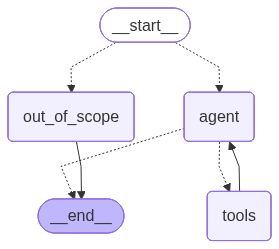

In [26]:
try:
    display(Image(langgraph_routed_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("Could not render Mermaid PNG. Mermaid source follows:\n")
    print(langgraph_routed_agent.get_graph().draw_mermaid())
    print(f"\nRender error: {exc}")

In [16]:
def print_langgraph_routed_agent_stream(question: str):
    """Run the explicit LangGraph agent and print each graph update."""
    inputs = {"messages": [{"role": "user", "content": question}]}

    for chunk in langgraph_routed_agent.stream(inputs, stream_mode="updates"):
        for node_name, update in chunk.items():
            print(f"\n--- Update from node: {node_name} ---")
            messages = update.get("messages", [])
            if not messages:
                print(update)
                continue

            latest_message = messages[-1]
            if isinstance(latest_message, ToolMessage):
                print(f"Tool result preview:\n{latest_message.content[:1200]}")
            elif hasattr(latest_message, "pretty_print"):
                latest_message.pretty_print()
            else:
                print(latest_message)

In [44]:
print_langgraph_routed_agent_stream("What urinary signs need urgent care?")

Top retrieval similarity score: 0.56

--- Update from node: agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_zKke5ztW0IBvCDAXexcdxqFt)
 Call ID: call_zKke5ztW0IBvCDAXexcdxqFt
  Args:
    query: urinary signs that need urgent care in cats emergency warning signs blood in urine straining inability to urinate frequent litter box trips pain

--- Update from node: tools ---
Tool result preview:
[Source 1: cat_health_guidelines.md, chunk_id=4, start_index=2463, score=0.784]
## Litter Box And Urinary Warning Signs

Changes in litter box behavior can signal stress, pain, urinary disease, constipation, diarrhea, or other illness. Owners should pay attention to straining, frequent trips to the litter box, crying in the box, blood in urine, urinating outside the box, producing very little urine, or not producing urine.

A cat that is straining to urinate, repeatedly visiting the litter box, crying, or pro

In [45]:
print_langgraph_routed_agent_stream("Who won the 2022 World Cup?")

Top retrieval similarity score: 0.04

--- Update from node: out_of_scope ---
================================== Ai Message ==================================

I can only help with cat health related questions.


In [ ]:
print_langgraph_routed_agent_stream("What fun activities can I do with my cat?")

Top retrieval similarity score: 0.43

--- Update from node: agent ---
================================== Ai Message ==================================

This notebook is scoped to the cat health guideline corpus, and I don’t have enough information in the cat health guidelines to answer about fun activities.


### 📝 Activity #2 Notes

- Which questions bypassed the model-tools loop?
- What happened with the ambiguous question?
- What are the cost, latency, and quality trade-offs of this route?

##### Answer:

1. The unrelated "Who won the 2022 World Cup?" bypassed the model-tools loop, and caused the graph to advance through the deterministic route: The start node called the "out_of_scope_condition" function as defined in the conditional edge. since the similarity score was below the defined threshold, the updated state routed to the out_of_scope node, which returned the AI message: "I can only help with cat health related questions."
2. The ambiguous question routed to the agent node, which in turn decided not to use the tool and per instructed in the SYSTEM_PROMPT, formulated and returned an answer that the question is out of the scope of the cat health guideline corpus.
3. The deterministic route has minimal cost and latency, as it doesn't even use an llm call and only runs the vector_store.similarity_search_with_score function, and makes a simple threshold check. On the other hand, as we learned in the previous assignment, a high similarity score means that the textual meaning is similar, it doesn't mean the query is in context with the retrieval. Which is why with the ambiguous question "What fun activities can I do with my cat?", the start node conditional edge function routed it to the agent node.
    - Also, if a question is phrased unusually, it might legitimately be in context but will fail the similarity score check and wrongfully get routed away from the agent node.
    - Another note - The threshold I chose needs to be evaluated for multiple examples and tuned to get more consistent results.  

## 🚧 Advanced Build (Optional): Add Explicit Retrieval Quality Control

The base assignment shows the minimal agentic RAG loop two ways:

1. `create_agent`
2. explicit LangGraph

If you want more control, extend the explicit LangGraph version with retrieval quality control. Good advanced additions include:

- Add a document relevance grader after retrieval.
- Add a query rewrite node when retrieval is weak.
- Add a loop limit so the agent cannot keep retrying forever.
- Add a deterministic guardrail before answering.

Those are useful production patterns, but they are not required for the core idea of agentic RAG.

In [17]:
# Advanced build workspace

from typing import Literal
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage


class RAGState(MessagesState):
    grade: str        
    retries: int     

MAX_RETRIES = 2       

GRADE_PROMPT = """You grade whether retrieved context is relevant and sufficient to answer a cat health question.

  Question:
  {question}

  Retrieved context:
  {context}

  Answer with exactly one word: 'high' if relevant and sufficient, otherwise 'low'."""

REWRITE_PROMPT = """The previous retrieval was not relevant enough. Rewrite the question into a better search query for a cat health guideline corpus.
 Reply with ONLY the rewritten query. 
 Original question: {question}"""

GENERATE_PROMPT = """You are a cat health guideline assistant. Answer using ONLY the retrieved context in the conversation.
 Add a short Sources line. Remind the user to contact a veterinarian for medical decisions or worsening symptoms.
 If the context is insufficient, say you do not have enough information in the cat health guidelines to answer."""



def _first_question(state) -> str:   
    return next((m.content for m in state["messages"] if isinstance(m, HumanMessage)), "")


def _latest_context(state) -> str:   
    return next((m.content for m in reversed(state["messages"]) if isinstance(m, ToolMessage)), "")



def grade(state):                   
    verdict = llm.invoke([SystemMessage(content=GRADE_PROMPT.format(
        question=_first_question(state), context=_latest_context(state)))])
    g = "high" if "high" in verdict.content.strip().lower() else "low"
    print(f"[grader] retrieval -> {g}")
    return {"grade": g}


def rewrite_query(state):           
    refined = llm.invoke([SystemMessage(content=REWRITE_PROMPT.format(
        question=_first_question(state)))]).content.strip()
    print(f"[rewrite] new query -> {refined}")
    return {"retries": state.get("retries", 0) + 1,
            "messages": [HumanMessage(content=f"That wasn't enough. Search the guidelines for: {refined}")]}


def generate(state):                 
    response = llm.invoke([SystemMessage(content=GENERATE_PROMPT)] + state["messages"])
    return {"messages": [response]}

def guardrail(state):
    return {"messages": [AIMessage(content=
        "I don't have enough information in the cat health guidelines to answer that. "
        "Please consult a veterinarian for medical decisions.")]}    


def grade_router(state) -> Literal["generate", "rewrite_query", "guardrail"]:
    if state["grade"] == "high":
        return "generate"                    # good context → let LLM answer
    if state.get("retries", 0) >= MAX_RETRIES:
        return "guardrail"                   # gave up, still low → deterministic refusal
    return "rewrite_query"          


extended_routing_builder = StateGraph(RAGState)
extended_routing_builder.add_node("out_of_scope", out_of_scope_message)                       
extended_routing_builder.add_node("agent", call_model)                                        
extended_routing_builder.add_node("tools", ToolNode([retriever_tool], handle_tool_errors=True)) 
extended_routing_builder.add_node("grade", grade)                                             
extended_routing_builder.add_node("rewrite_query", rewrite_query)                             
extended_routing_builder.add_node("generate", generate)
extended_routing_builder.add_node("guardrail", guardrail)                                      

extended_routing_builder.add_conditional_edges(START, out_of_scope_condition)   
extended_routing_builder.add_edge("out_of_scope", END)
extended_routing_builder.add_conditional_edges("agent", tools_condition)        
extended_routing_builder.add_edge("tools", "grade")                             
extended_routing_builder.add_conditional_edges("grade", grade_router)          
extended_routing_builder.add_edge("rewrite_query", "agent")                     
extended_routing_builder.add_edge("generate", END)
extended_routing_builder.add_edge("guardrail", END)                              

extended_routing_agent = extended_routing_builder.compile()
print("Compiled the retrieval-quality-control graph (extends the Activity #2 routed graph).")

Compiled the retrieval-quality-control graph (extends the Activity #2 routed graph).


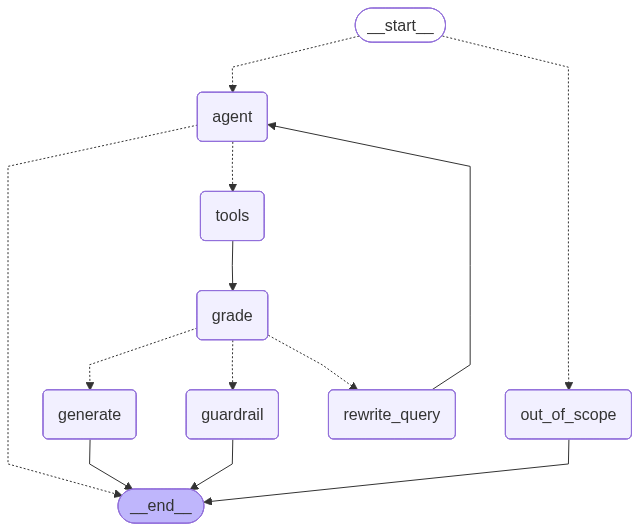

In [18]:
try:
    display(Image(extended_routing_agent.get_graph().draw_mermaid_png()))
except Exception as exc:
    print(extended_routing_agent.get_graph().draw_mermaid())
    print("Render error:", exc)

In [19]:
def print_extended_routing_agent(question: str):
      """Stream the retrieval-quality-control graph and print each node update."""
      inputs = {"messages": [{"role": "user", "content": question}], "retries": 0}  # init counter
      for chunk in extended_routing_agent.stream(inputs, stream_mode="updates"):
          for node, update in chunk.items():
              print(f"\n--- {node} ---")
              msgs = (update or {}).get("messages", []) if isinstance(update, dict) else []
              if msgs and hasattr(msgs[-1], "pretty_print"):
                  msgs[-1].pretty_print()
              elif msgs:
                  print(msgs[-1])
                  print(update)

In [20]:
print_extended_routing_agent("How can I help my cat?")


Top retrieval similarity score: 0.54

--- agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_IMuVVL6X9xlxAZXw7jWouQHx)
 Call ID: call_IMuVVL6X9xlxAZXw7jWouQHx
  Args:
    query: general guidance on how to help a cat, home care, when to contact veterinarian, cat health monitoring, preventive care

--- tools ---
================================= Tool Message =================================
Name: retrieve_cat_health_guidelines

[Source 1: cat_health_guidelines.md, chunk_id=1, start_index=268, score=0.657]
## Preventive Care

Healthy adult cats should have a wellness exam at least once per year. Kittens, senior cats, cats with chronic disease, and cats taking long-term medication may need more frequent visits. A wellness visit may include a weight check, dental exam, vaccine review, parasite prevention review, and discussion of behavior, appetite, hydration, litter box habits, and activity level.



In [21]:
print_extended_routing_agent("How do I trim my cat's nails?")


Top retrieval similarity score: 0.36

--- agent ---
================================== Ai Message ==================================
Tool Calls:
  retrieve_cat_health_guidelines (call_a5aBAJHJ0uvdwFGJ1BzemmEt)
 Call ID: call_a5aBAJHJ0uvdwFGJ1BzemmEt
  Args:
    query: How to trim cat nails safely at home, nail trimming steps, restraint, what to avoid, when to seek veterinary help

--- tools ---
================================= Tool Message =================================
Name: retrieve_cat_health_guidelines

[Source 1: cat_health_guidelines.md, chunk_id=9, start_index=5435, score=0.515]
## Safe Home Monitoring

Home monitoring is useful when it supports, rather than replaces, veterinary care. Owners can record appetite, water intake, litter box output, medication doses, body weight, vomiting episodes, stool quality, and behavior changes. Photos or videos can help a veterinarian understand symptoms that are hard to describe.

Do not give human medication to a cat unless a veterinaria

  What I changed:
  - Extended the Activity #2 routed graph into a retrieval-quality-control loop. Kept the START → out_of_scope_condition deterministic gate, then after tools added four nodes: grade, rewrite_query,
  generate, guardrail.
  - main code changes: 
  - added appropriate conditional edges and their appropriate functions (grade (high/low), rewrite_query, generate, guardrail, grade router)
  - New state (RAGState which inherits MessagesState with grade + retries), MAX_RETRIES = 2.
  - New flow: tools → grade → either generate (context grade is high) or rewrite_query → agent (retry with a reformulated query), or guardrail (give up safely).

  Why I changed it
  - The base loop lets the model answer off whatever it retrieved, even when that context is weak — risking ungrounded/incomplete answers.
  - Adding an explicit LLM grader + rewrite-and-retry makes retrieval quality a controlled step.
  - The guardrail guarantees a safe deterministic refusal after MAX_RETRIES instead of letting the model hallucinate when retrieval keeps failing.

  How retrieval decisions / answer quality changed
  - When first retrieval graded low, the agent reformulated and re-retrieved instead of answering from poor context. 
  - When context stayed low after 2 retries, it returned the guardrail refusal "I don't have enough information in the cat health guidelines to answer that. Please consult a veterinarian for medical decisions.", rather than a weak answer.
  

---
## Summary

In this session, you:

1. Built a retrieval tool over a Qdrant vector store.
2. Used `create_agent` and middleware for a high-level agentic RAG loop.
3. Streamed agent runs to inspect when retrieval happened.
4. Rebuilt the loop explicitly with LangGraph nodes and conditional edges.
5. Practiced choosing between middleware-level constraints and graph-level routing.

### Key Takeaways

- Agentic RAG makes retrieval an available action instead of a mandatory pre-step.
- Tool contracts and system prompts strongly influence retrieval decisions.
- Middleware is useful for cross-cutting behavior such as logging, limits, retries, and guardrails.
- Explicit graphs are useful when the application needs custom state or control flow.
- Inspecting intermediate events is essential because a plausible final answer can hide a poor agent path.

### Further Reading

- [LangChain Agents](https://docs.langchain.com/oss/python/langchain/agents)
- [LangChain Middleware](https://docs.langchain.com/oss/python/langchain/middleware)
- [LangGraph Overview](https://docs.langchain.com/oss/python/langgraph/overview)
- [LangSmith Observability](https://docs.langchain.com/langsmith/observability)

### Notebook Output Guidance

Keep useful outputs when you submit, especially graph diagrams and representative streamed runs that support your observations. Remove secrets, failed experiments that no longer matter, and excessively noisy output.